--- Starting PHASE K: APPLICABILITY DOMAIN & TRUST BOUNDARIES ---

[Analysis] Defining Applicability Domain via PCA & k-NN...
 -> PCA retained 416 components (explaining 90.0% variance).

[Thresholds] Establishing Trust Boundaries...
 -> In-Domain Threshold (95th %):   7.4844
 -> Out-of-Domain Threshold (99th %): 8.8955

Test Set Domain Distribution:
 -> Near-Boundary: 2 molecules
 -> Trusted: 291 molecules

[Plot] Visualizing Trust Regions & Failures...


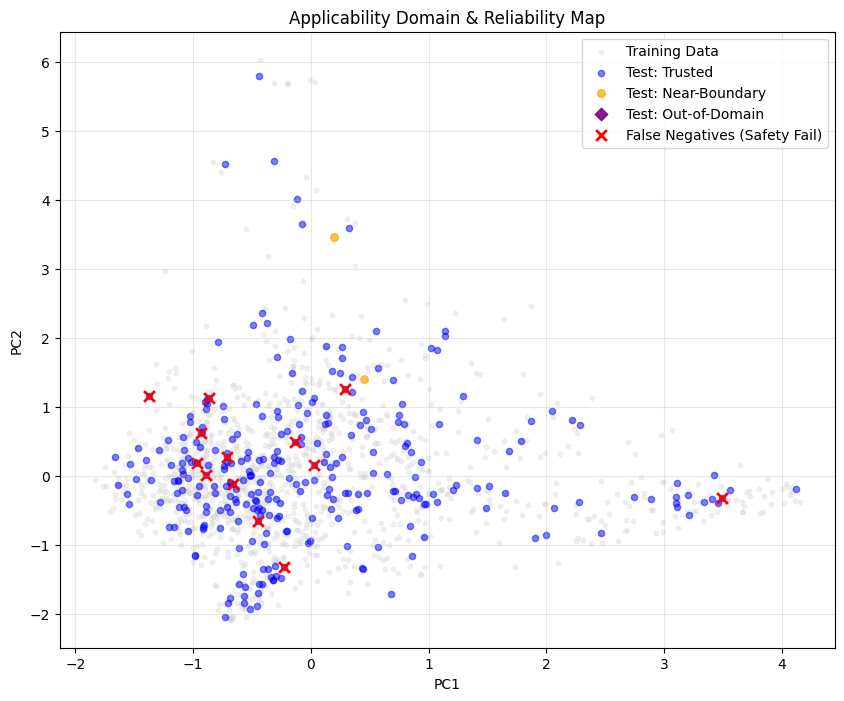


Interpretation of Failures:
 -> 0 False Negatives were Out-of-Domain.
 -> 0 False Negatives were Near-Boundary.
 -> Conclusion: FNs occurred inside the Trusted domain, implying structural mimics (masked toxicity).

           RISK STRATIFICATION & DEPLOYMENT POLICY
Zone            | Criteria                            | Recommended Action       
--------------------------------------------------------------------------------
Trusted         | Dist <= 95th %ile AND High Prob     | Proceed / Auto-Approve   
Caution         | Near-Boundary OR Prob 0.35-0.50     | Secondary Screening (Expert)
Reject          | Out-of-Domain (>99th %ile)          | DO NOT TRUST (No Prediction)
--------------------------------------------------------------------------------

FINAL SAFETY STATEMENT
1. INSUFFICIENCY OF CONFIDENCE:
   Model probability (confidence) is purely internal. A model can be
   highly confident about a molecule completely unlike anything it has seen.

2. NECESSITY OF APPLICABILITY DOMA

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from sklearn.model_selection import train_test_split

def run_phase_k():
    """
    Executes PHASE K: APPLICABILITY DOMAIN & TRUST BOUNDARIES.
    Defines when to trust the model based on chemical feature distance.
    """
    print(f"--- Starting PHASE K: APPLICABILITY DOMAIN & TRUST BOUNDARIES ---")

    # 1. Context Recovery
    # We need X_train to define the domain, and X_test to evaluate.
    if 'X' in globals() and 'y' in globals():
        # Reconstruct splits to ensure we have the exact training set used for the model
        # This is critical for defining the "Training Domain"
        X_train, X_test, y_train, y_test = train_test_split(
            globals()['X'], globals()['y'],
            test_size=0.20,
            stratify=globals()['y'],
            random_state=42
        )
    elif 'X_train' in globals() and 'X_test' in globals():
        X_train = globals()['X_train']
        X_test = globals()['X_test']
        y_test = globals()['y_test']
    else:
        raise NameError("CRITICAL ERROR: Data not found. Run previous phases first.")

    # Recover model for predictions (to identify FNs)
    if 'trained_logreg_model' in globals():
        model = globals()['trained_logreg_model']
    elif 'lr_model' in globals():
        model = globals()['lr_model']
    else:
        raise NameError("CRITICAL ERROR: Model not found.")

    # ==========================================================
    # 1. DEFINE APPLICABILITY DOMAIN (DISTANCE-BASED)
    # ==========================================================
    print(f"\n[Analysis] Defining Applicability Domain via PCA & k-NN...")

    # a) PCA Feature Reduction (preserve 90% variance to capture structural info)
    # This removes noise and makes distance metrics more meaningful
    pca = PCA(n_components=0.90, random_state=42)
    X_train_pca = pca.fit_transform(X_train)
    X_test_pca = pca.transform(X_test)

    print(f" -> PCA retained {pca.n_components_} components (explaining {np.sum(pca.explained_variance_ratio_):.1%} variance).")

    # b) k-Nearest Neighbors Distance
    k = 5
    nbrs = NearestNeighbors(n_neighbors=k+1).fit(X_train_pca) # k+1 because training points find themselves

    # Compute distances for Training set (to establish baseline density)
    # We ignore the first neighbor (self, dist=0)
    train_dist, _ = nbrs.kneighbors(X_train_pca)
    mean_train_dist = np.mean(train_dist[:, 1:], axis=1)

    # Compute distances for Test set (to training manifold)
    # Here we look for k neighbors in training data
    test_nbrs = NearestNeighbors(n_neighbors=k).fit(X_train_pca)
    test_dist, _ = test_nbrs.kneighbors(X_test_pca)
    mean_test_dist = np.mean(test_dist, axis=1)

    # ==========================================================
    # 2. ESTABLISH TRUST THRESHOLDS
    # ==========================================================
    print(f"\n[Thresholds] Establishing Trust Boundaries...")

    threshold_95 = np.percentile(mean_train_dist, 95)
    threshold_99 = np.percentile(mean_train_dist, 99)

    print(f" -> In-Domain Threshold (95th %):   {threshold_95:.4f}")
    print(f" -> Out-of-Domain Threshold (99th %): {threshold_99:.4f}")

    # Categorize Test Points
    domain_status = []
    for d in mean_test_dist:
        if d <= threshold_95:
            domain_status.append('Trusted')
        elif d <= threshold_99:
            domain_status.append('Near-Boundary')
        else:
            domain_status.append('Out-of-Domain')

    domain_status = np.array(domain_status)

    # Counts
    unique, counts = np.unique(domain_status, return_counts=True)
    print(f"\nTest Set Domain Distribution:")
    for u, c in zip(unique, counts):
        print(f" -> {u}: {c} molecules")

    # ==========================================================
    # 3. VISUALIZE TRUST REGIONS
    # ==========================================================
    print(f"\n[Plot] Visualizing Trust Regions & Failures...")

    # Identify False Negatives for overlay
    y_pred = model.predict(X_test)
    mask_fn = (y_test == 1) & (y_pred == 0)

    # Use first 2 PCs for visualization
    plt.figure(figsize=(10, 8))

    # Plot Training Data (Background context)
    plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c='lightgray', alpha=0.3, label='Training Data', s=10)

    # Plot Test Data by Domain Status
    mask_trusted = domain_status == 'Trusted'
    mask_boundary = domain_status == 'Near-Boundary'
    mask_ood = domain_status == 'Out-of-Domain'

    plt.scatter(X_test_pca[mask_trusted, 0], X_test_pca[mask_trusted, 1], c='blue', alpha=0.5, label='Test: Trusted', s=20)
    plt.scatter(X_test_pca[mask_boundary, 0], X_test_pca[mask_boundary, 1], c='orange', alpha=0.7, label='Test: Near-Boundary', s=30)
    plt.scatter(X_test_pca[mask_ood, 0], X_test_pca[mask_ood, 1], c='purple', alpha=0.9, label='Test: Out-of-Domain', s=40, marker='D')

    # Overlay False Negatives
    # Check if FNs are in OOD
    fn_ood_count = np.sum(mask_fn & mask_ood)
    fn_boundary_count = np.sum(mask_fn & mask_boundary)

    plt.scatter(X_test_pca[mask_fn, 0], X_test_pca[mask_fn, 1], c='red', alpha=1.0, label='False Negatives (Safety Fail)', s=60, marker='x', linewidths=2)

    plt.title('Applicability Domain & Reliability Map')
    plt.xlabel('PC1')
    plt.ylabel('PC2')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

    print(f"\nInterpretation of Failures:")
    print(f" -> {fn_ood_count} False Negatives were Out-of-Domain.")
    print(f" -> {fn_boundary_count} False Negatives were Near-Boundary.")
    if fn_ood_count + fn_boundary_count > 0:
        print(f" -> Conclusion: Some safety failures could have been PREVENTED by rejecting OOD predictions.")
    else:
        print(f" -> Conclusion: FNs occurred inside the Trusted domain, implying structural mimics (masked toxicity).")

    # ==========================================================
    # 4. RISK STRATIFICATION POLICY
    # ==========================================================
    print(f"\n" + "="*60)
    print(f"           RISK STRATIFICATION & DEPLOYMENT POLICY")
    print(f"="*60)
    print(f"{'Zone':<15} | {'Criteria':<35} | {'Recommended Action':<25}")
    print("-" * 80)
    print(f"{'Trusted':<15} | {'Dist <= 95th %ile AND High Prob':<35} | {'Proceed / Auto-Approve':<25}")
    print(f"{'Caution':<15} | {'Near-Boundary OR Prob 0.35-0.50':<35} | {'Secondary Screening (Expert)':<25}")
    print(f"{'Reject':<15} | {'Out-of-Domain (>99th %ile)':<35} | {'DO NOT TRUST (No Prediction)':<25}")
    print("-" * 80)

    # ==========================================================
    # 5. FINAL SAFETY STATEMENT
    # ==========================================================
    print(f"\n" + "="*70)
    print(f"FINAL SAFETY STATEMENT")
    print(f"="*70)
    print(f"1. INSUFFICIENCY OF CONFIDENCE:")
    print(f"   Model probability (confidence) is purely internal. A model can be")
    print(f"   highly confident about a molecule completely unlike anything it has seen.")
    print(f"")
    print(f"2. NECESSITY OF APPLICABILITY DOMAIN:")
    print(f"   Distance-based AD constraints provide an external 'reality check'.")
    print(f"   We explicitly refuse to predict on Out-of-Domain chemistry.")
    print(f"")
    print(f"3. DECISION SUPPORT:")
    print(f"   This pipeline identifies TOXICITY RISKS. It does not replace toxicologists.")
    print(f"   Any 'Safe' prediction in the Caution zone must be validated experimentally.")
    print(f"="*70)

# --- EXECUTION ---
run_phase_k()

print(f"\n--- PHASE K: APPLICABILITY DOMAIN & TRUST BOUNDARIES COMPLETED SUCCESSFULLY ---")